# HBC515 end-to-end SIGMA validation

This example runs the public `sigma-omics` API on HBC515 without importing code from the original notebook. It preserves the validated HBC515 model settings and writes all outputs to a new validation directory. The original data and notebooks are read-only inputs.

In [1]:
from pathlib import Path
import json
import platform
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import sigma_spatial
from sigma_spatial import run_sigma
from sigma_spatial.plotting import save_figure, set_publication_style, style_spatial_axis

set_publication_style()
SEED = 0
PROJECT_ROOT = Path.cwd().resolve().parents[1]
DATA_FILE = PROJECT_ROOT / 'HBC_515' / 'BC_515_Section_1.h5ad'
REFERENCE_FILE = PROJECT_ROOT / 'HBC_515' / 'clean' / 'results' / 'HBC515_SIGMA_core.h5ad'
OUTPUT_DIR = PROJECT_ROOT / 'HBC_515' / 'clean' / 'results' / 'pypi_validation_0.1.1'
FIGURE_DIR = OUTPUT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print({'python': platform.python_version(), 'sigma_spatial': sigma_spatial.__version__, 'input': str(DATA_FILE)})

Matplotlib is building the font cache; this may take a moment.


{'python': '3.11.13', 'sigma_spatial': '0.1.1', 'input': '/Users/dubingxue/Desktop/SIGMA-Code-Clean/HBC_515/BC_515_Section_1.h5ad'}


## 1. Load the public input and construct weak anchors

In [2]:
adata = ad.read_h5ad(DATA_FILE)
annotation = adata.obs['annotation'].astype(str)
adata.obs['sigma_anchor'] = np.select(
    [annotation.eq('Tumor'), annotation.eq('Stroma')],
    [1.0, 0.0],
    default=np.nan,
)
print(adata)
print(adata.obs['sigma_anchor'].value_counts(dropna=False).sort_index())

AnnData object with n_obs × n_vars = 3508 × 15953
    obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'annotation', 'sigma_anchor'
    uns: 'msi', 'mz_features', 'orig.ident_colors', 'seurat_clusters_colors', 'spatial'
    obsm: 'X_harmony', 'X_pca', 'X_umap', 'spatial'
    layers: 'log1p', 'raw'
sigma_anchor
0.0    2707
1.0     724
NaN      77
Name: count, dtype: int64


## 2. Run the published SIGMA API

These are the frozen HBC515 reference settings: 64 MSI components, directed Gaussian kNN with k=15, 1,000 epochs, supervision weight 0.05, RNA alignment weight 0.05, and boundary k=10.

In [3]:
result = run_sigma(
    adata,
    anchor_key='sigma_anchor',
    representation_key='X_harmony',
    spatial_key='spatial',
    copy=True,
    n_components=64,
    n_neighbors=15,
    random_state=SEED,
    z_dim=32,
    epochs=1000,
    lr=1e-3,
    lambda_sup=0.05,
    beta_rna=0.05,
    boundary_k=10,
)
result.write_h5ad(OUTPUT_DIR / 'HBC515_sigma_omics_0.1.1.h5ad')

## 3. Review and save the essential SIGMA fields

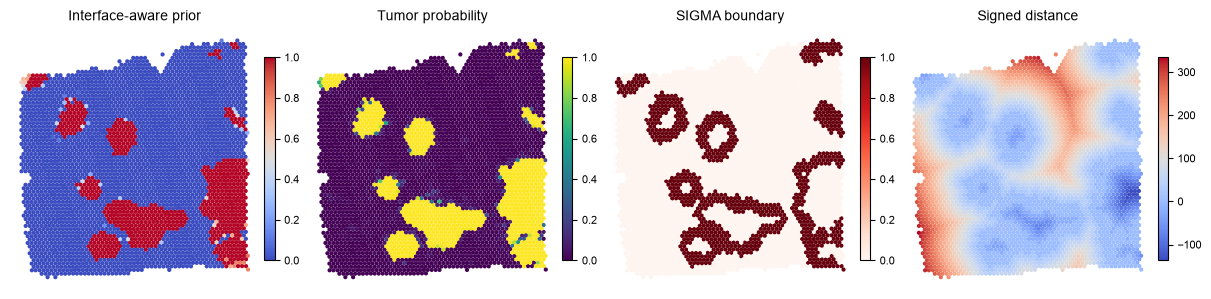

In [4]:
xy = np.asarray(result.obsm['spatial'])
panels = [
    ('sigma_gaussian_anchor', 'Interface-aware prior', 'coolwarm'),
    ('sigma_region_probability', 'Tumor probability', 'viridis'),
    ('sigma_boundary', 'SIGMA boundary', 'Reds'),
    ('sigma_d_signed', 'Signed distance', 'coolwarm'),
]
fig, axes = plt.subplots(1, 4, figsize=(12.0, 3.0), constrained_layout=True)
for ax, (key, title, cmap) in zip(axes, panels):
    values = result.obs[key].to_numpy()
    artist = ax.scatter(xy[:, 0], xy[:, 1], c=values, s=4, cmap=cmap, rasterized=True)
    ax.set_title(title)
    style_spatial_axis(ax)
    fig.colorbar(artist, ax=ax, shrink=0.72, pad=0.02)
save_figure(fig, FIGURE_DIR / 'HBC515_public_api_core_fields', formats=('pdf', 'svg', 'png'))
plt.show()

## 4. Numerical preservation check against the frozen reference

In [5]:
reference = ad.read_h5ad(REFERENCE_FILE, backed='r')
checks = {}
for key in ['sigma_region_probability', 'sigma_d_signed']:
    observed = result.obs[key].to_numpy(dtype=float)
    expected = reference.obs[key].to_numpy(dtype=float)
    checks[key] = {
        'correlation': float(np.corrcoef(observed, expected)[0, 1]),
        'mae': float(np.mean(np.abs(observed - expected))),
    }
checks['sigma_boundary'] = {
    'agreement': float(np.mean(result.obs['sigma_boundary'].to_numpy() == reference.obs['sigma_boundary'].to_numpy()))
}
pd.DataFrame(checks).T.to_csv(OUTPUT_DIR / 'HBC515_public_api_regression.csv')
print(json.dumps(checks, indent=2))

{
  "sigma_region_probability": {
    "correlation": 0.9965843883435396,
    "mae": 0.007837431518785208
  },
  "sigma_d_signed": {
    "correlation": 0.9989346990565798,
    "mae": 0.6597907852317996
  },
  "sigma_boundary": {
    "agreement": 0.9948688711516533
  }
}


## 5. Display the preserved HBC515 influence-range distribution

The current public API reproduces the SIGMA core. The provenance-locked HBC515 lambda table is loaded here for reporting; lambda estimation will become a public report component in a later release.

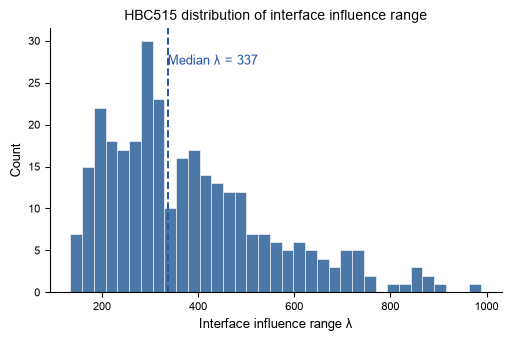

In [6]:
lambda_table = pd.read_csv(PROJECT_ROOT / 'HBC_515' / 'clean' / 'results' / 'BC515_lambda_ranking.csv')
lambda_values = pd.to_numeric(lambda_table['lambda'], errors='coerce')
lambda_values = lambda_values[np.isfinite(lambda_values) & (lambda_values > 0)]
median_lambda = float(np.median(lambda_values))
fig, ax = plt.subplots(figsize=(5.0, 3.3), constrained_layout=True)
ax.hist(lambda_values, bins=35, color='#4C78A8', edgecolor='white', linewidth=0.4)
ax.axvline(median_lambda, color='#2457A7', linestyle='--', linewidth=1.4)
ax.text(median_lambda, ax.get_ylim()[1] * 0.90, f'Median λ = {median_lambda:.0f}', color='#2457A7', ha='left', va='top')
ax.set(xlabel='Interface influence range λ', ylabel='Count', title='HBC515 distribution of interface influence range')
ax.spines[['top', 'right']].set_visible(False)
save_figure(fig, FIGURE_DIR / 'HBC515_lambda_distribution', formats=('pdf', 'svg', 'png'))
plt.show()

## Outputs

The validation directory contains the new H5AD result, a regression table, and publication-ready PDF/SVG/PNG figures. Simulation, cross-method benchmark, GO enrichment and manuscript assembly remain separate downstream analyses.